In [496]:
from pyspark.sql import SparkSession
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler

import seaborn as sns
import matplotlib.pyplot as plt

In [497]:
LABEL_COLUMN='price'
SEED=42

spark = SparkSession.builder \
    .appName("Airbnb") \
    .config("spark.driver.memory", "20g") \
    .config("spark.driver.maxResultSize", "6g") \
    .config("spark.memory.fraction", "0.8") \
    .config("spark.memory.storageFraction", "0.2") \
    .config("spark.sql.shuffle.partitions", "16") \
    .config("spark.shuffle.file.buffer", "1m") \
    .config("spark.driver.extraJavaOptions",
            "-XX:+UseG1GC -XX:G1HeapRegionSize=16m -XX:+ParallelRefProcEnabled") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

raw_df = (
    spark.read
    .option("header", "true")
    .option("sep", ",")
    .option("multiLine", "true")
    .option("quote", "\"")
    .option("escape", "\"")
    .option("mode", "PERMISSIVE")
    .parquet("./total_data.parquet")
)

raw_df.createOrReplaceTempView('raw_listing')

In [498]:
selected_df = spark.sql("""
    SELECT
        latitude,
        longitude,
        host_is_superhost,
        host_listings_count,
        property_type,
        accommodates,
        bathrooms,
        bedrooms,
        beds,
        amenities,
        price,
        require_guest_profile_picture,
        require_guest_phone_verification, 
        month,
        security_deposit,
        cleaning_fee
    FROM raw_listing
""")

selected_df.createOrReplaceTempView("selected_df")

## Initial Parsing

In [499]:
selected_df.show()

+-------------------+-------------------+-----------------+-------------------+------------------+------------+---------+--------+----+--------------------+---------+-----------------------------+--------------------------------+-----+----------------+------------+
|           latitude|          longitude|host_is_superhost|host_listings_count|     property_type|accommodates|bathrooms|bedrooms|beds|           amenities|    price|require_guest_profile_picture|require_guest_phone_verification|month|security_deposit|cleaning_fee|
+-------------------+-------------------+-----------------+-------------------+------------------+------------+---------+--------+----+--------------------+---------+-----------------------------+--------------------------------+-----+----------------+------------+
|-22.965919031411442| -43.17896230586568|                f|                2.0|       Condominium|           5|      1.0|     2.0| 2.0|{TV,"Cable TV",In...|  $307.00|                            f|      

In [500]:
selected_df.createOrReplaceTempView('selected_df')
row_count = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
print(f'Rows: {row_count}, Columns: {len(selected_df.columns)}')

Rows: 784122, Columns: 16


In [501]:
selected_df.createOrReplaceTempView("selected_df")
null_count_expr = ",\n    ".join([
    f"SUM(CASE WHEN `{c}` IS NULL THEN 1 ELSE 0 END) AS `{c}`"
    for c in selected_df.columns
])
spark.sql(f"SELECT\n    {null_count_expr}\nFROM selected_df").show()

+--------+---------+-----------------+-------------------+-------------+------------+---------+--------+----+---------+-----+-----------------------------+--------------------------------+-----+----------------+------------+
|latitude|longitude|host_is_superhost|host_listings_count|property_type|accommodates|bathrooms|bedrooms|beds|amenities|price|require_guest_profile_picture|require_guest_phone_verification|month|security_deposit|cleaning_fee|
+--------+---------+-----------------+-------------------+-------------+------------+---------+--------+----+---------+-----+-----------------------------+--------------------------------+-----+----------------+------------+
|       1|        1|              386|                386|            1|           1|     1494|     776|2335|        1|    1|                            2|                               2|    2|          361064|      269336|
+--------+---------+-----------------+-------------------+-------------+------------+---------+-----

As we can see there's a lot of missing values in the `security_deposit` and `cleaning_fee` columns.

Dropping them from the database seems to be a good decision.

In [502]:
selected_df.createOrReplaceTempView('selected_df')
rows_before_drop = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
selected_df = spark.sql("""
    SELECT
        latitude, longitude, host_is_superhost, host_listings_count,
        property_type, accommodates, bathrooms, bedrooms, beds,
        amenities, price, require_guest_profile_picture,
        require_guest_phone_verification, month
    FROM selected_df
""")

In [503]:
selected_df.createOrReplaceTempView('selected_df')
selected_df = spark.sql("""
    SELECT * FROM selected_df
    WHERE latitude IS NOT NULL
      AND longitude IS NOT NULL
      AND host_is_superhost IS NOT NULL
      AND host_listings_count IS NOT NULL
      AND property_type IS NOT NULL
      AND accommodates IS NOT NULL
      AND bathrooms IS NOT NULL
      AND bedrooms IS NOT NULL
      AND beds IS NOT NULL
      AND amenities IS NOT NULL
      AND price IS NOT NULL
      AND require_guest_profile_picture IS NOT NULL
      AND require_guest_phone_verification IS NOT NULL
      AND month IS NOT NULL
""")
selected_df.createOrReplaceTempView('selected_df')
row_count = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
print(f"({row_count}, {len(selected_df.columns)}) - {rows_before_drop - row_count} rows dropped")

(780035, 14) - 4087 rows dropped


Checking if there is any missing left:

In [504]:
selected_df.createOrReplaceTempView("selected_df")
null_count_expr = ",\n    ".join([
    f"SUM(CASE WHEN `{c}` IS NULL THEN 1 ELSE 0 END) AS `{c}`"
    for c in selected_df.columns
])
spark.sql(f"SELECT\n    {null_count_expr}\nFROM selected_df").show()


+--------+---------+-----------------+-------------------+-------------+------------+---------+--------+----+---------+-----+-----------------------------+--------------------------------+-----+
|latitude|longitude|host_is_superhost|host_listings_count|property_type|accommodates|bathrooms|bedrooms|beds|amenities|price|require_guest_profile_picture|require_guest_phone_verification|month|
+--------+---------+-----------------+-------------------+-------------+------------+---------+--------+----+---------+-----+-----------------------------+--------------------------------+-----+
|       0|        0|                0|                  0|            0|           0|        0|       0|   0|        0|    0|                            0|                               0|    0|
+--------+---------+-----------------+-------------------+-------------+------------+---------+--------+----+---------+-----+-----------------------------+--------------------------------+-----+



### Checking data types

In [505]:
selected_df.printSchema()

root
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- host_is_superhost: string (nullable = true)
 |-- host_listings_count: string (nullable = true)
 |-- property_type: string (nullable = true)
 |-- accommodates: string (nullable = true)
 |-- bathrooms: string (nullable = true)
 |-- bedrooms: string (nullable = true)
 |-- beds: string (nullable = true)
 |-- amenities: string (nullable = true)
 |-- price: string (nullable = true)
 |-- require_guest_profile_picture: string (nullable = true)
 |-- require_guest_phone_verification: string (nullable = true)
 |-- month: string (nullable = true)



### Checking data types

In [506]:
selected_df = spark.sql("""
    SELECT
        TRY_CAST(latitude AS DOUBLE) AS latitude,
        TRY_CAST(longitude AS DOUBLE) AS longitude,
        TRY_CAST(host_is_superhost AS BOOLEAN) AS host_is_superhost,
        TRY_CAST(TRY_CAST(host_listings_count AS DOUBLE) AS INT) AS host_listings_count,
        property_type,
        TRY_CAST(TRY_CAST(accommodates AS DOUBLE) AS INT) AS accommodates,
        TRY_CAST(TRY_CAST(bathrooms AS DOUBLE) AS INT) AS bathrooms,
        TRY_CAST(TRY_CAST(bedrooms AS DOUBLE) AS INT) AS bedrooms,
        TRY_CAST(TRY_CAST(beds AS DOUBLE) AS INT) AS beds,
        amenities,
        TRY_CAST(REGEXP_REPLACE(price, '[\\\\$,]', '') AS DOUBLE) AS price,
        TRY_CAST(require_guest_profile_picture AS BOOLEAN) AS require_guest_profile_picture,
        TRY_CAST(require_guest_phone_verification AS BOOLEAN) AS require_guest_phone_verification, 
        TRY_CAST(month AS INT) AS month
    FROM selected_df
""")

selected_df.createOrReplaceTempView("selected_df")

null_count_expr = ",\n    ".join([
    f"SUM(CASE WHEN `{c}` IS NULL THEN 1 ELSE 0 END) AS `{c}`"
    for c in selected_df.columns
])
spark.sql(f"SELECT\n    {null_count_expr}\nFROM selected_df").show()

+--------+---------+-----------------+-------------------+-------------+------------+---------+--------+----+---------+-----+-----------------------------+--------------------------------+-----+
|latitude|longitude|host_is_superhost|host_listings_count|property_type|accommodates|bathrooms|bedrooms|beds|amenities|price|require_guest_profile_picture|require_guest_phone_verification|month|
+--------+---------+-----------------+-------------------+-------------+------------+---------+--------+----+---------+-----+-----------------------------+--------------------------------+-----+
|       0|        0|                0|                  0|            0|           0|        0|       0|   0|        0|    0|                            0|                               0|    0|
+--------+---------+-----------------+-------------------+-------------+------------+---------+--------+----+---------+-----+-----------------------------+--------------------------------+-----+



## EDA + Data Cleaning

In [507]:
def get_max_fence(column):
    row = spark.sql(f"""
        SELECT
            PERCENTILE_APPROX(`{column}`, 0.25) AS q1,
            PERCENTILE_APPROX(`{column}`, 0.75) AS q3
        FROM selected_df
    """).first()
    q1, q3 = row['q1'], row['q3']
    iqr = q3 - q1
    return q3 + 1.5 * iqr

def box_plot(column):
    column_pd = selected_df.select(column).toPandas()[column]
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.set_size_inches(16,6)
    _ = sns.boxplot(x=column_pd, ax = ax1, color='green')
    ax1.set_title(f'{column} boxplot')
    ax2.set_title(f'{column} boxplot com zoom')
    ax2.set_xlim((-0.1,1.1*get_max_fence(column)))
    _ = sns.boxplot(x=column_pd, ax = ax2, color='green')

def hist_plot(column):
    column_pd = selected_df.select(column).toPandas()[column]

    plt.figure(figsize=(10, 6))
    plt.hist(column_pd, bins=50, edgecolor="black")
    plt.title(f"Distribuicao de valores do {column}")
    plt.xlabel(column)
    plt.ylabel("Frequencia")
    plt.show()

#### `host_listings_count`

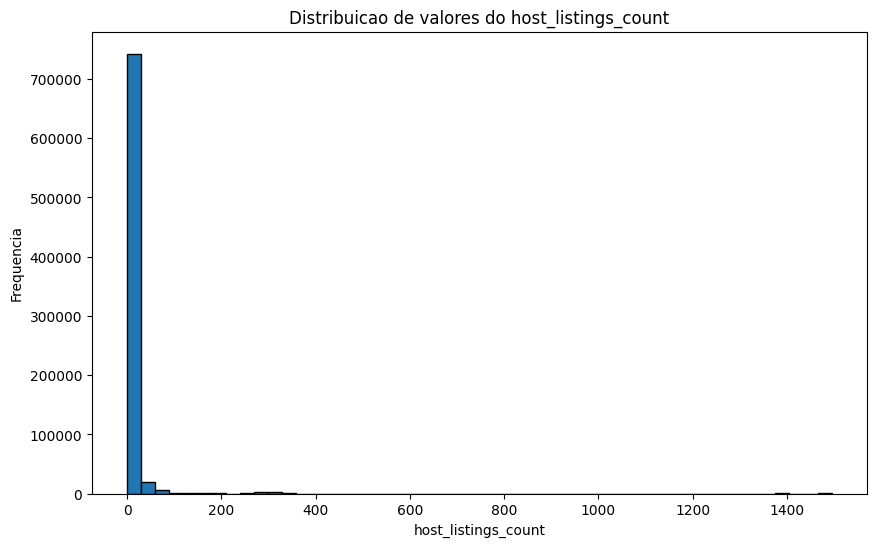

In [508]:
hist_plot("host_listings_count")

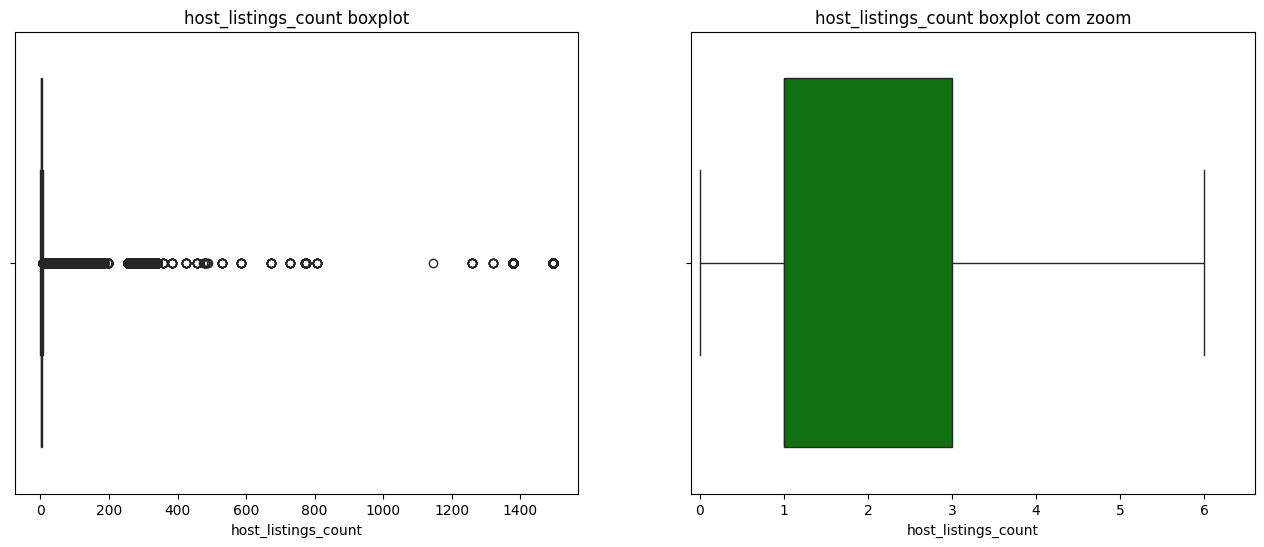

In [509]:
box_plot("host_listings_count")

In [510]:
listing_count_max_fence = get_max_fence('host_listings_count')
print(listing_count_max_fence)

6.0


In [511]:
selected_df.createOrReplaceTempView('selected_df')
rows_before = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
selected_df = spark.sql(f"""
    SELECT *
    FROM selected_df
    WHERE host_listings_count <= {listing_count_max_fence}
""")
selected_df.createOrReplaceTempView('selected_df')
rows_after = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
print(f"{rows_before - rows_after} rows were deleted.")

99528 rows were deleted.


In [512]:
selected_df.createOrReplaceTempView('selected_df')
selected_df = spark.sql("""
    SELECT
        latitude,
        longitude,
        host_is_superhost,
        CASE WHEN host_listings_count = 0.0 THEN 1.0 ELSE host_listings_count END AS host_listings_count,
        property_type,
        accommodates,
        bathrooms,
        bedrooms,
        beds,
        amenities,
        price,
        require_guest_profile_picture,
        require_guest_phone_verification,
        month
    FROM selected_df
""")

#### `price`

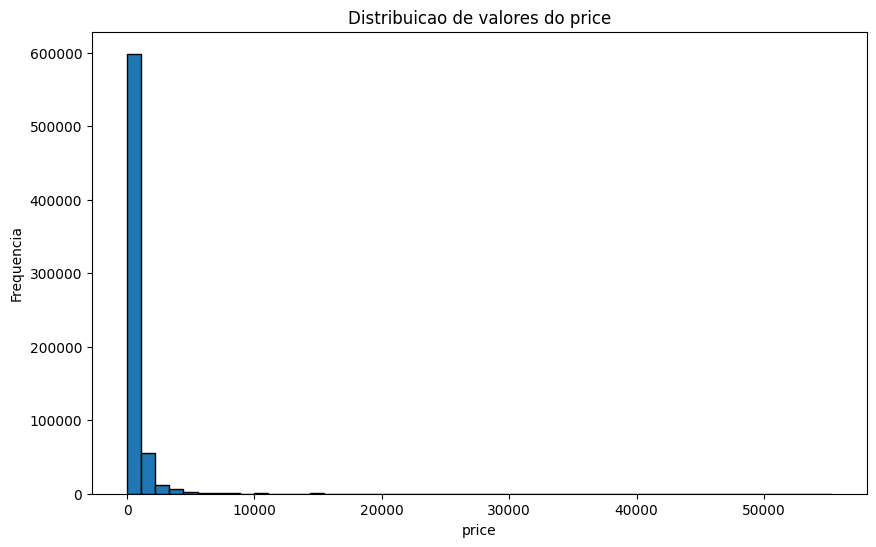

In [513]:
hist_plot("price")

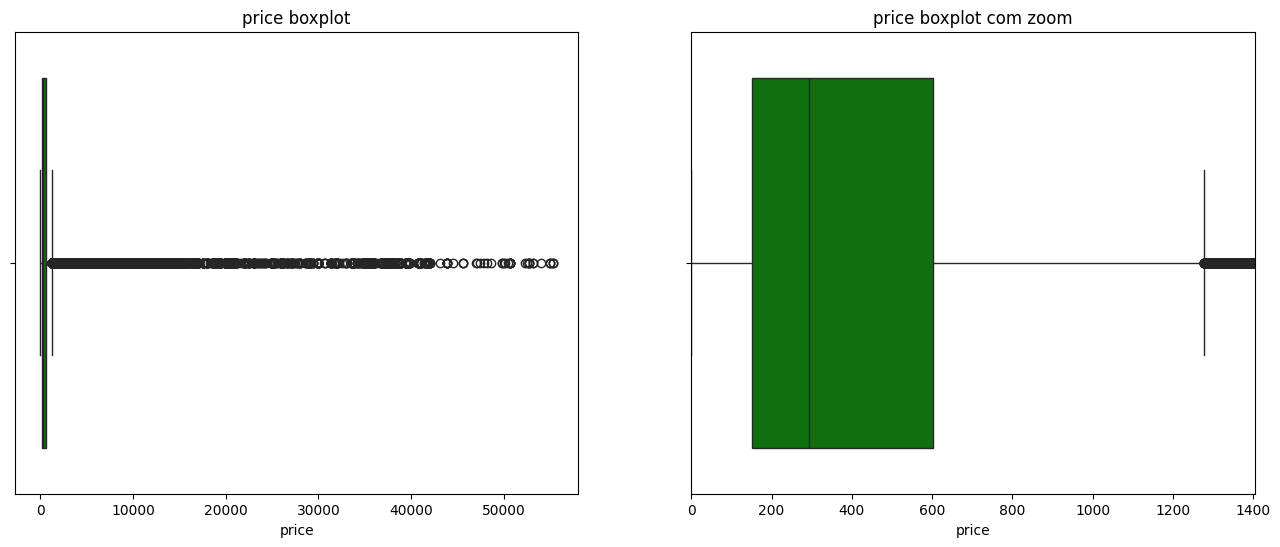

In [514]:
box_plot("price")

In [515]:
price_max_fence = get_max_fence('price')
print(price_max_fence)

1276.0


In [516]:
selected_df.createOrReplaceTempView('selected_df')
rows_before = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
selected_df = spark.sql(f"""
    SELECT *
    FROM selected_df
    WHERE price <= {price_max_fence}
""")
selected_df.createOrReplaceTempView('selected_df')
rows_after = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
print(f"{rows_before - rows_after} rows were deleted.")

66365 rows were deleted.


#### `property_type`

In [517]:
categories_to_append = ('Aparthotel', 'Earth house', 'Chalet', 'Cottage', 'Tiny house',
                        'Boutique hotel', 'Hotel', 'Casa particular (Cuba)', 'Bungalow',
                        'Nature lodge', 'Cabin', 'Castle', 'Treehouse', 'Island', 'Boat', 'Tent',
                        'Resort', 'Hut', 'Campsite', 'Barn', 'Dorm', 'Camper/RV', 'Farm stay', 'Yurt',
                        'Tipi', 'Pension (South Korea)', 'Dome house', 'Igloo', 'Casa particular',
                        'Houseboat', 'Lighthouse', 'Plane', 'Train', 'Parking Space')

category_list_sql = ", ".join([f"'" + c.replace("'", "''") + "'" for c in categories_to_append])
selected_df.createOrReplaceTempView('selected_df')
selected_df = spark.sql(f"""
    SELECT
        latitude,
        longitude,
        host_is_superhost,
        host_listings_count,
        CASE WHEN property_type IN ({category_list_sql}) THEN 'Other' ELSE property_type END AS property_type,
        accommodates,
        bathrooms,
        bedrooms,
        beds,
        amenities,
        price,
        require_guest_profile_picture,
        require_guest_phone_verification,
        month
    FROM selected_df
""")

#### `beds`

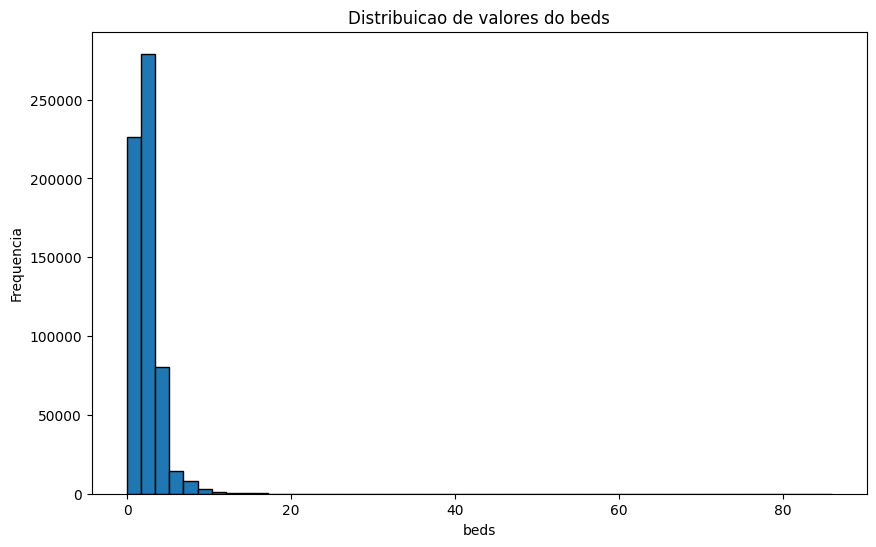

In [518]:
hist_plot("beds")

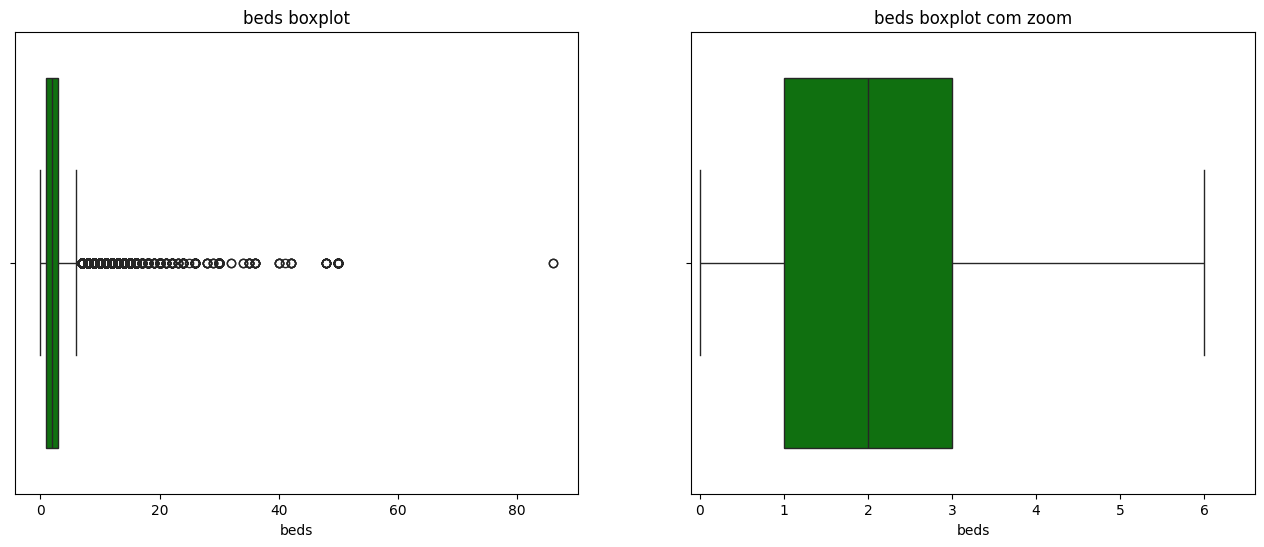

In [519]:
box_plot("beds")

In [520]:
beds_max_fence = get_max_fence('beds')
print(beds_max_fence)

6.0


In [521]:
selected_df.createOrReplaceTempView('selected_df')
rows_before = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
selected_df = spark.sql(f"""
    SELECT *
    FROM selected_df
    WHERE beds <= {beds_max_fence}
""")
selected_df.createOrReplaceTempView('selected_df')
rows_after = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
print(f"{rows_before - rows_after} rows were deleted.")

13846 rows were deleted.


#### `amenities`

In [522]:
selected_df.createOrReplaceTempView('selected_df')
selected_df = spark.sql("""
    SELECT
        latitude,
        longitude,
        host_is_superhost,
        host_listings_count,
        property_type,
        accommodates,
        bathrooms,
        bedrooms,
        beds,
        amenities,
        price,
        require_guest_profile_picture,
        require_guest_phone_verification,
        month,
        SIZE(SPLIT(amenities, ',')) + 1 AS n_amenities
    FROM selected_df
""")
selected_df.createOrReplaceTempView('selected_df')
mode_value = spark.sql("""
    SELECT n_amenities
    FROM selected_df
    WHERE amenities <> '{}'
    GROUP BY n_amenities
    ORDER BY COUNT(*) DESC
    LIMIT 1
""").first()['n_amenities']
selected_df = spark.sql(f"""
    SELECT
        latitude,
        longitude,
        host_is_superhost,
        host_listings_count,
        property_type,
        accommodates,
        bathrooms,
        bedrooms,
        beds,
        price,
        require_guest_profile_picture,
        require_guest_phone_verification,
        month,
        CASE WHEN amenities = '{{}}' THEN {mode_value} ELSE n_amenities END AS n_amenities
    FROM selected_df
""")

In [523]:
amenities_max_fence = get_max_fence('n_amenities')
print(amenities_max_fence)

42.0


In [524]:
selected_df.createOrReplaceTempView('selected_df')
rows_before = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
selected_df = spark.sql(f"""
    SELECT *
    FROM selected_df
    WHERE n_amenities <= {amenities_max_fence}
""")
selected_df.createOrReplaceTempView('selected_df')
rows_after = spark.sql("SELECT COUNT(*) AS cnt FROM selected_df").first()['cnt']
print(f"{rows_before - rows_after} rows were deleted.")

17635 rows were deleted.


In [ ]:
df_density_mapbox = selected_df.sample(n=15000)
map_center = {'lat':df_density_mapbox.latitude.mean(), 'lon':df_density_mapbox.longitude.mean()}
fig = px.density_mapbox(df_density_mapbox, lat='latitude', lon='longitude',z='price',title=10*'  '+'Daily Price density', radius=2.5,
                        center=map_center, zoom=10,
                        mapbox_style='stamen-terrain')
fig.show()

## Mapa de calor do Rio de Janeiro

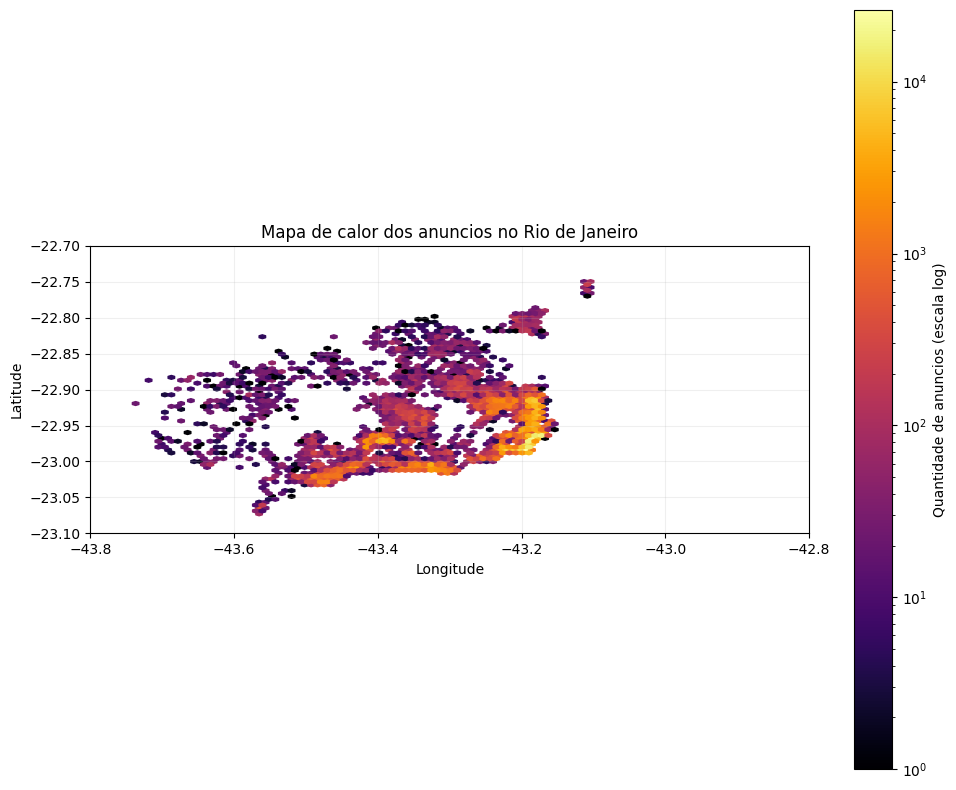

In [526]:
rio_lat_min, rio_lat_max = -23.10, -22.70
rio_lon_min, rio_lon_max = -43.80, -42.80

rio_map_pd = (
    selected_df
    .select('latitude', 'longitude')
    .dropna(subset=['latitude', 'longitude'])
    .where(
        f"latitude BETWEEN {rio_lat_min} AND {rio_lat_max} "
        f"AND longitude BETWEEN {rio_lon_min} AND {rio_lon_max}"
    )
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.hexbin(
    rio_map_pd['longitude'],
    rio_map_pd['latitude'],
    gridsize=70,
    cmap='inferno',
    bins='log',
    mincnt=1
)

fig.colorbar(heatmap, ax=ax, label='Quantidade de anuncios (escala log)')
ax.set_xlim(rio_lon_min, rio_lon_max)
ax.set_ylim(rio_lat_min, rio_lat_max)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mapa de calor dos anuncios no Rio de Janeiro')
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Matriz de correlacao

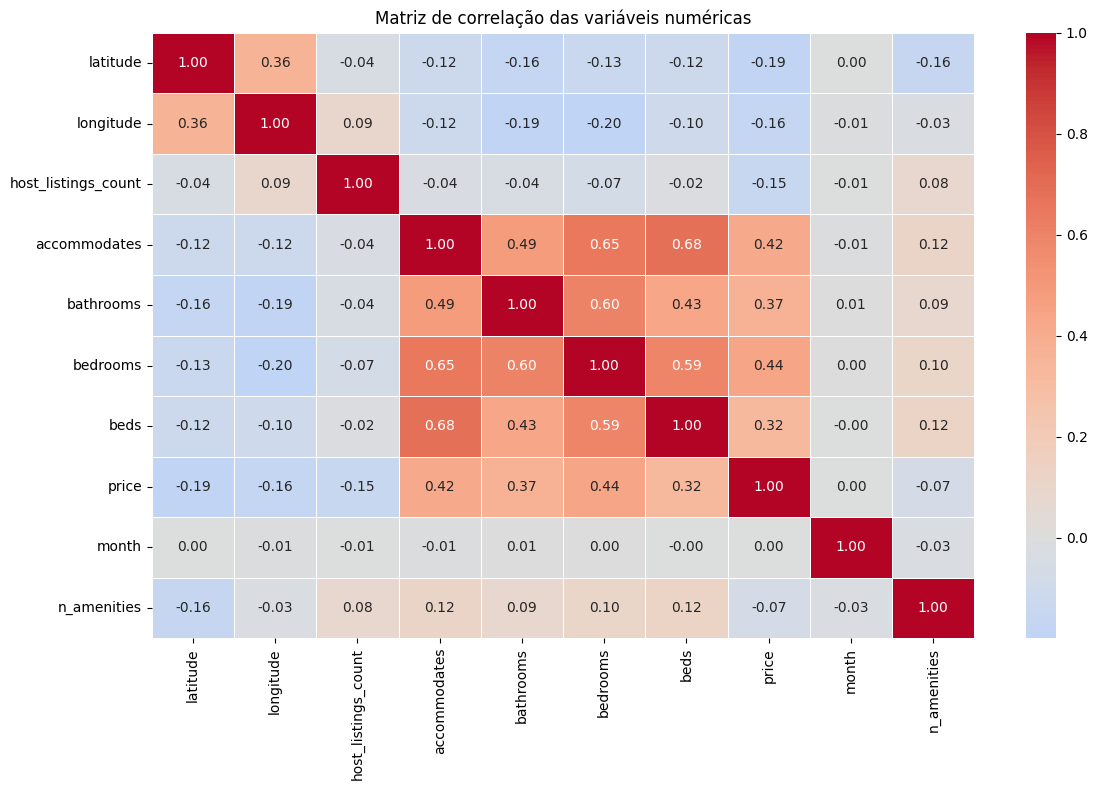

In [527]:
numeric_types = {'int', 'bigint', 'double', 'float', 'decimal', 'smallint', 'tinyint'}
numeric_columns = [
    column_name
    for column_name, column_type in selected_df.dtypes
    if column_type.split('(')[0] in numeric_types
]

correlation_pd = selected_df.select(numeric_columns).toPandas()
correlation_matrix = correlation_pd.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)
plt.title('Matriz de correlação das variáveis numéricas')
plt.tight_layout()
plt.show()

## Encoding

In [528]:
selected_df.createOrReplaceTempView('selected_df')
df_label_encoder = spark.sql("""
    WITH property_type_index AS (
        SELECT
            property_type,
            ROW_NUMBER() OVER (ORDER BY cnt DESC, property_type ASC) - 1 AS property_type_encoded
        FROM (
            SELECT property_type, COUNT(*) AS cnt
            FROM selected_df
            GROUP BY property_type
        )
    )
    SELECT
        s.latitude,
        s.longitude,
        CASE
            WHEN s.host_is_superhost IS TRUE THEN 1
            WHEN s.host_is_superhost IS FALSE THEN 0
            ELSE CAST(s.host_is_superhost AS INT)
        END AS host_is_superhost,
        s.host_listings_count,
        p.property_type_encoded AS property_type,
        s.accommodates,
        s.bathrooms,
        s.bedrooms,
        s.beds,
        s.price,
        CASE
            WHEN s.require_guest_profile_picture IS TRUE THEN 1
            WHEN s.require_guest_profile_picture IS FALSE THEN 0
            ELSE CAST(s.require_guest_profile_picture AS INT)
        END AS require_guest_profile_picture,
        CASE
            WHEN s.require_guest_phone_verification IS TRUE THEN 1
            WHEN s.require_guest_phone_verification IS FALSE THEN 0
            ELSE CAST(s.require_guest_phone_verification AS INT)
        END AS require_guest_phone_verification,
        s.month,
        s.n_amenities
    FROM selected_df s
    LEFT JOIN property_type_index p
        ON s.property_type = p.property_type
""")
print('Columns encoded')

Columns encoded


In [529]:
df_label_encoder.createOrReplaceTempView("df_label_encoder")
df_label_encoder = spark.sql("""
    SELECT *,
        CAST(
            CASE
                WHEN price < 200  THEN 0
                WHEN price < 500  THEN 1
                ELSE 2
            END
        AS DOUBLE) AS price_band
    FROM df_label_encoder
""")
df_label_encoder.createOrReplaceTempView("df_label_encoder")
print("Band distribution (0=budget<200, 1=mid 200-499, 2=premium>=500):")
spark.sql("""
    SELECT price_band, COUNT(*) AS cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM df_label_encoder
    GROUP BY price_band
    ORDER BY price_band
""").show()

Band distribution (0=budget<200, 1=mid 200-499, 2=premium>=500):


+----------+------+----+
|price_band|   cnt| pct|
+----------+------+----+
|       0.0|232001|39.8|
|       1.0|211311|36.3|
|       2.0|139349|23.9|
+----------+------+----+



## Model

In [530]:
models = [
    ("Linear Regression", LinearRegression(
        labelCol=LABEL_COLUMN, featuresCol="features",
        maxIter=200, regParam=0.01, elasticNetParam=0.0
    )),
    ("Decision Tree Regressor", DecisionTreeRegressor(
        labelCol=LABEL_COLUMN, featuresCol="features",
        maxDepth=30, minInstancesPerNode=15, minInfoGain=0.0, maxBins=32, seed=SEED
    )),
    ("MLP Classifier", MultilayerPerceptronClassifier(
        labelCol="price_band", featuresCol="features",
        layers=[13, 16, 3], maxIter=50, blockSize=512,
        solver="l-bfgs", seed=SEED
    )),
]

In [531]:
feature_cols = [
    "host_is_superhost",
    "host_listings_count",
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "month",
    "property_type",
    "require_guest_profile_picture",
    "require_guest_phone_verification",
    "n_amenities"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
prepared_df = assembler.transform(df_label_encoder)
train_prepared, test_prepared = prepared_df.randomSplit([0.8, 0.2], seed=SEED)

In [532]:
def evaluate_regression_model(model_name: str, predictions) -> None:
    predictions = predictions.cache()

    rmse = RegressionEvaluator(labelCol=LABEL_COLUMN, predictionCol="prediction", metricName="rmse").evaluate(predictions)
    mae  = RegressionEvaluator(labelCol=LABEL_COLUMN, predictionCol="prediction", metricName="mae").evaluate(predictions)
    r2   = RegressionEvaluator(labelCol=LABEL_COLUMN, predictionCol="prediction", metricName="r2").evaluate(predictions)

    print(f"\n{model_name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.6f}")

    predictions.unpersist()


def evaluate_classification_model(model_name: str, predictions) -> None:
    predictions = predictions.cache()
    predictions.createOrReplaceTempView("mlp_predictions")

    accuracy = MulticlassClassificationEvaluator(
        labelCol="price_band", predictionCol="prediction", metricName="accuracy"
    ).evaluate(predictions)
    f1 = MulticlassClassificationEvaluator(
        labelCol="price_band", predictionCol="prediction", metricName="f1"
    ).evaluate(predictions)

    print(f"\n{model_name} (0=<200, 1=200-499, 2=>=500)")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    spark.sql("""
        SELECT price_band,
               SUM(CASE WHEN price_band = prediction THEN 1 ELSE 0 END) AS correct,
               COUNT(*) AS total,
               ROUND(SUM(CASE WHEN price_band = prediction THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS acc_pct
        FROM mlp_predictions
        GROUP BY price_band
        ORDER BY price_band
    """).show()

    predictions.unpersist()

In [533]:
for model_name, estimator in models:
    model = estimator.fit(train_prepared)
    predictions = model.transform(test_prepared)

    if isinstance(estimator, MultilayerPerceptronClassifier):
        evaluate_classification_model(model_name, predictions)
    else:
        evaluate_regression_model(model_name, predictions)


Linear Regression
RMSE: 241.16
MAE: 180.28
R2: 0.291856


ERROR:root:KeyboardInterrupt while sending command.                             
Traceback (most recent call last):
  File "/Users/enzoalencar/Documents/Faculdade/bigdata-ac2/.venv/lib/python3.13/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/Users/enzoalencar/Documents/Faculdade/bigdata-ac2/.venv/lib/python3.13/site-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/enzoalencar/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
KeyboardInterrupt


KeyboardInterrupt: 